In [1]:
# Load dataset

!git clone https://github.com/1-aditya-singh/personal-finance-intelligence-system.git

Cloning into 'personal-finance-intelligence-system'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 55 (delta 32), reused 32 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 166.46 KiB | 4.62 MiB/s, done.
Resolving deltas: 100% (32/32), done.


In [3]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df=pd.read_csv("personal-finance-intelligence-system/data/transactions.csv")
df["date"] = pd.to_datetime(df["date"])
df['month'] = df['date'].dt.to_period('M')

income = df[df["type"]=='Income']
expenses = df[df["type"]=='Expense']
df.head()

,id,date,type,category,amount,description,month
0,1,2026-09-01,Income,Salary,30000,Monthly salary,2026-09
1,2,2026-09-02,Expense,Food,250,Lunch,2026-09
2,3,2026-09-03,Expense,Travel,500,Cab to college,2026-09
3,4,2026-09-04,Expense,Shopping,1200,Clothes,2026-09
4,5,2026-09-05,Expense,Food,180,Breakfast,2026-09


In [6]:
# monthly financial summary
monthly_income = income.groupby('month')['amount'].sum()

monthly_expense = expenses.groupby('month')['amount'].sum()

monthly_summary = pd.DataFrame({'income': monthly_income, 'expenses': monthly_expense})

monthly_summary['savings'] = monthly_summary['income'] - monthly_summary['expenses']

monthly_summary['savings_rate'] = (
    monthly_summary['savings']
    / monthly_summary['income']

)*100

monthly_summary["savings_rate"] = (
    monthly_summary["savings_rate"].round(2)
)

monthly_summary

,income,expenses,savings,savings_rate
month,,,,
2026-09,35000,10870,24130,68.94
2026-10,33500,11600,21900,65.37
2026-11,34500,5730,28770,83.39


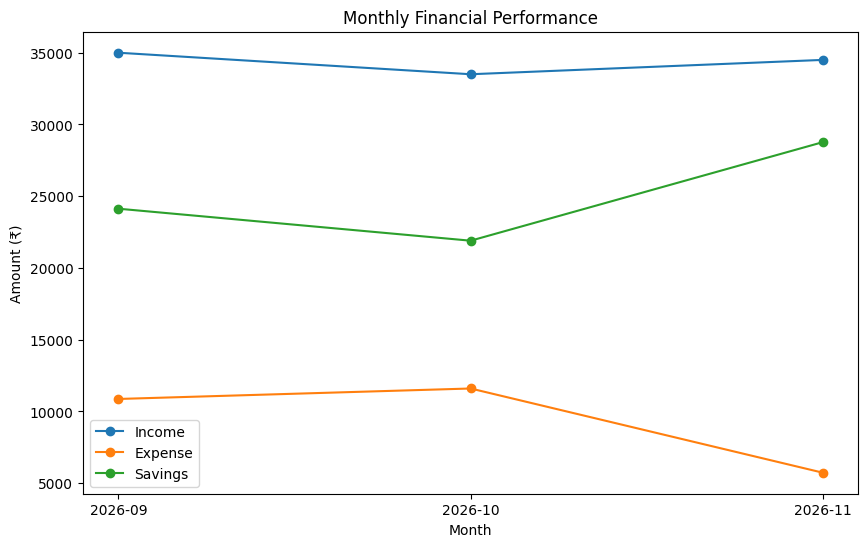

In [8]:
# Financial Performance graph
plt.figure(figsize=(10, 6))

x = monthly_summary.index.astype(str)

plt.plot(
    x,
    monthly_summary["income"],
    marker="o",
    label="Income"
)

plt.plot(
    x,
    monthly_summary["expenses"],
    marker="o",
    label="Expense"
)

plt.plot(
    x,
    monthly_summary["savings"],
    marker="o",
    label="Savings"
)

plt.title("Monthly Financial Performance")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.legend()

plt.show()

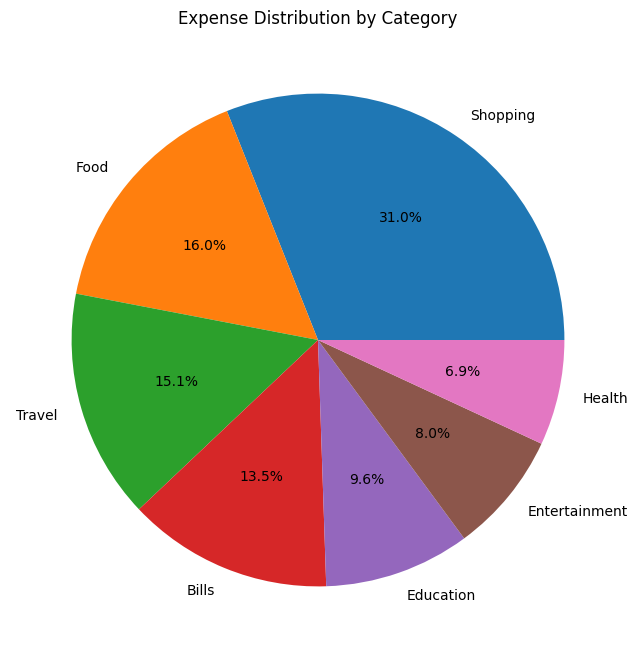

In [9]:
# Expense Distribution graph
category_spending = expenses.groupby('category')['amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))

plt.pie(
    category_spending.values,
    labels=category_spending.index,
    autopct="%1.1f%%"
)

plt.title("Expense Distribution by Category")

plt.show()

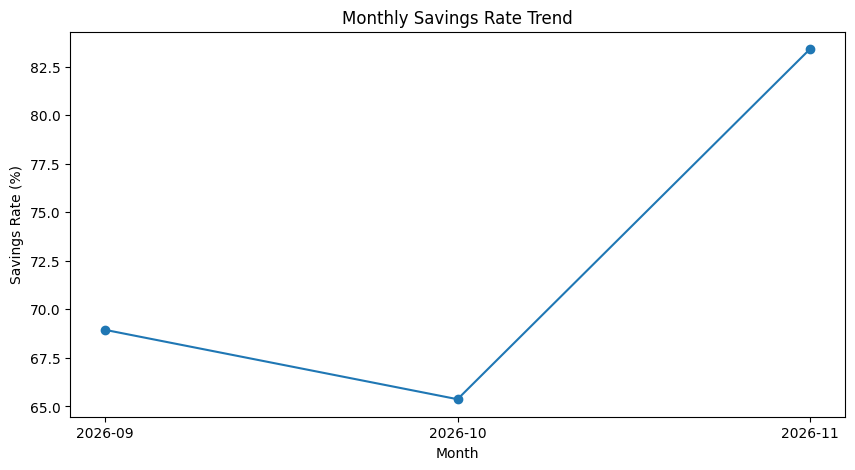

In [10]:
# Savings Rate Trend chart
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["savings_rate"],
    marker="o"
)

plt.title("Monthly Savings Rate Trend")
plt.xlabel("Month")
plt.ylabel("Savings Rate (%)")

plt.show()

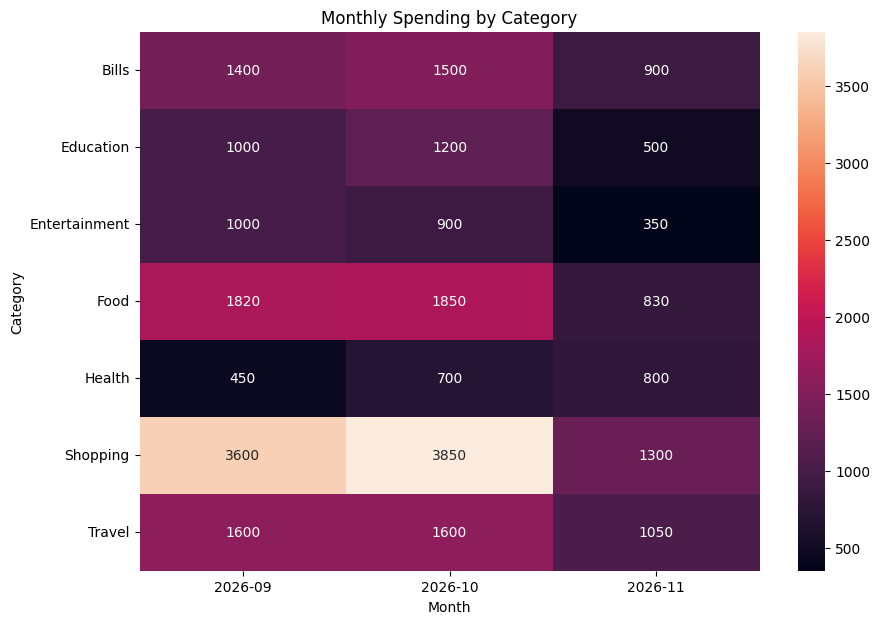

In [11]:
# Spending Heatmap graph
category_monthly = (
    expenses
    .groupby(["category", "month"])["amount"]
    .sum()
    .unstack(fill_value=0)
)

category_monthly
plt.figure(figsize=(10, 7))

sns.heatmap(
    category_monthly,
    annot=True,
    fmt=".0f"
)

plt.title("Monthly Spending by Category")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [13]:
# the highest category-month combination
highest_category_month = category_monthly.stack().idxmax()
highest_category_month_amount = category_monthly.stack().max()

print(
    f"Highest category-month spending was "
    f"{highest_category_month[0]} in "
    f"{highest_category_month[1]} "
    f"with ₹{highest_category_month_amount}."
)


Highest category-month spending was Shopping in 2026-10 with ₹3850.


('Shopping', Period('2026-10', 'M'))

In [14]:
print("===================================")
print("   ADVANCED FINANCIAL ANALYSIS")
print("===================================")

print()

print(
    f"📊 Highest spending category: "
    f"{category_spending.index[0]} "
    f"(₹{category_spending.iloc[0]})"
)

print(
    f"📈 Best savings-rate month: "
    f"{monthly_summary['savings_rate'].idxmax()} "
    f"({monthly_summary['savings_rate'].max()}%)"
)

print(
    f"📉 Lowest savings-rate month: "
    f"{monthly_summary['savings_rate'].idxmin()} "
    f"({monthly_summary['savings_rate'].min()}%)"
)

print(
    f"🔥 Highest category-month spending: "
    f"{highest_category_month[0]} in "
    f"{highest_category_month[1]} "
    f"(₹{highest_category_month_amount})"
)

   ADVANCED FINANCIAL ANALYSIS

📊 Highest spending category: Shopping (₹8750)
📈 Best savings-rate month: 2026-11 (83.39%)
📉 Lowest savings-rate month: 2026-10 (65.37%)
🔥 Highest category-month spending: Shopping in 2026-10 (₹3850)
